In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 
from sklearn.mixture import GaussianMixture
# from sklearn.preprocessing import OrdinalEncoder
# from sklearn.cluster import DBSCAN
# from gower import gower_matrix


# import user functions
# import UserUtilityFunctions as uf
# import UserStatisticalFunctions as usf
# import UserVisualization as uv
# import UserMetricsFunctions as umf
import UserImputeFunctions as uif

# set seaborn theme
sns.set_theme()

# initializing variables
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 1.26.4
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


### Import Dataset

In [2]:
# import data
df = pd.read_pickle("../Data/5Clean_ML_Heart_CAT.pkl")
df_full = pd.read_pickle("../Data/5Clean_BeforeDummyEcode_CAT.pkl")

In [3]:
df.shape, df_full.shape

((15701, 218), (15701, 140))

In [5]:
# mapping values
df.Survival = df.Survival.map({'Dead': True, 'Living': False})

In [6]:
# change all boolean datatype to int
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

# defrag
df = df.copy()

In [7]:
df.head()

,PreviousTransplantNumber_CAN,EducationLevel_CAN,FunctionalStatusRegistration_CAN,FunctionalStatusTransplant_CAN,MedicalConditionTransplant_CAN,MismatchLevel_AMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,MismatchLevel_HLMIS,TransfusionNumber_DON,Survival,Age_CAT_CAN,Age_CAT_DON,HeightCm_CAT_CAN,HeightCm_CAT_DON,WeightKg_CAT_CAN,WeightKg_CAT_DON,BMI_CAT_CAN,BMI_CAT_DON,BloodUreaNitrogenLevel_CAT_DON,PanelReactiveAntibody_CPRA_CAT_CAN,Creatinine_CAT_CAN,Creatinine_CAT_DON,DistanceFromDonorHospitaltoTXCenter_CAT,Hematocrit_CAT_DON,Hemodynamics_Mean_PA_MN_CAT_CAN,Hemodynamics_Mean_CO_CAT_CAN,IschemicTimeHour_CAT,LV_EjectionFractionPercent_CAT_DON,SGOT_AST_Log_Addtion_CAT_DON,LungPO2_Addtion_CAT_DON,OrganRecovery_PCO2_CAT_DON,Bilirubin_CAT_CAN,Bilirubin_CAT_DON,TotalDayWaitList_CAT_CAN,Bronchoscopy_Combine_Count_DON,Cancer_Combined_Count_DON,DrugUse_Combnine_Count_DON,Dialysis_Combine_Count_CAN,Diuretics_Combine_Count_CAN,EpsteinBarr_Combine_Count_DON,Infection_Combine_Count_CAN,IntropesIV_Combine_Count_CAN,IntropesVasodilators_Combine_Count_CAN,LifeSupport_Combine_Count_CAN,PriorCardiacSurgery_Combine_Count_CAN,Ventilator_Combine_Count_CAN,WorkIncome_Combine_Count_CAN,BloodGroup_CAN_AB,BloodGroup_CAN_B,BloodGroup_CAN_O,BloodGroup_DON_A1,BloodGroup_DON_A2,BloodGroup_DON_AB,BloodGroup_DON_B,BloodGroup_DON_O,BloodGroupMatchLevel_Identical,InotropicAgent_DON_Dopamine,InotropicAgent_DON_Levophed,InotropicAgent_DON_Unknown,InotropicAgent_DON_Neosynephrine,"InotropicAgent_DON_Other, specify",HeavyAlcoholUse_DON_Unknown,HeavyAlcoholUse_DON_Yes,AntiHypertensive_DON_Yes,ArginnieManagement_DON_Yes,PrimaryDiagnosisType_CAN_CONGENITAL HEART DEFECT - WITH SURGERY,PrimaryDiagnosisType_CAN_CORONARY ARTERY DISEASE,PrimaryDiagnosisType_CAN_DILATED MYOPATHY: ADRIAMYCIN,PrimaryDiagnosisType_CAN_DILATED MYOPATHY: FAMILIAL,PrimaryDiagnosisType_CAN_DILATED MYOPATHY: IDIOPATHIC,PrimaryDiagnosisType_CAN_DILATED MYOPATHY: ISCHEMIC,PrimaryDiagnosisType_CAN_DILATED MYOPATHY: OTHER SPECIFY,PrimaryDiagnosisType_CAN_DILATED MYOPATHY: POST PARTUM,PrimaryDiagnosisType_CAN_HEART RE-TX/GF: CORONARY ARTERY DISEASE,PrimaryDiagnosisType_CAN_HYPERTROPHIC CARDIOMYOPATHY,PrimaryDiagnosisType_CAN_OTHER - SPECIFY,PrimaryDiagnosisType_CAN_RESTRICTIVE MYOPATHY: AMYLOIDOSIS,PrimaryDiagnosisType_CAN_RESTRICTIVE MYOPATHY: SARCOIDOSIS,PrimaryDiagnosisType_CAN_VALVULAR HEART DISEASE,DeathCircumstance_DON_DEATH FROM NATURAL CAUSES,DeathCircumstance_DON_HOMICIDE,DeathCircumstance_DON_MVA,DeathCircumstance_DON_NONE OF THE ABOVE,DeathCircumstance_DON_SUICIDE,DeathMechanism_DON_BLUNT INJURY,DeathMechanism_DON_CARDIOVASCULAR,DeathMechanism_DON_DEATH FROM NATURAL CAUSES,DeathMechanism_DON_DRUG INTOXICATION,DeathMechanism_DON_GUNSHOT WOUND,DeathMechanism_DON_INTRACRANIAL HEMORRHAGE/STROKE,DeathMechanism_DON_NONE OF THE ABOVE,AntigenBW4_CAN_Positive,AntigenBW6_CAN_Positive,AntigenC1_CAN_Positive,AntigenC2_CAN_Positive,AntigenDR2_DON_Positive,AntigenDR51_CAN_Positive,AntigenDR51_2_CAN_Positive,AntigenDR52_CAN_Positive,AntigenDR52_2_CAN_Positive,AntigenDR53_CAN_Positive,AntigenDR53_2_CAN_Positive,Diabetes_DON_Yes,DiabetesType_CAN_Type I,DiabetesType_CAN_Type II,CerebroVascularDisease_CAN_Yes,Malignancy_CAN_No,Malignancy_CAN_Yes,DefibrillatorImplantRegistration_CAN_Unknown,DefibrillatorImplantRegistration_CAN_Yes,IntropicMedicationProcurement_DON_Yes,CigaretteUse_CAN_Yes,CigaretteHistory_DON_Unknown,CigaretteHistory_DON_Yes,PriorCardiacSurgery_CAN_2,PriorCardiacSurgery_CAN_3,PriorCardiacSurgeryListAndTransplant_CAN_2,PriorCardiacSurgeryListAndTransplant_CAN_3,StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect,StatusAtTransplant_CAN_Other left Heart Valvar/Structural Hypoplasia; T

### Mapping Label & Split Data

In [8]:
from sklearn.model_selection import train_test_split

# split X & y
X = df.drop(columns = 'Survival')
y = df.Survival

# mapping values
# y = y.map({'Dead': True, 'Living': False})

# split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

### GMM

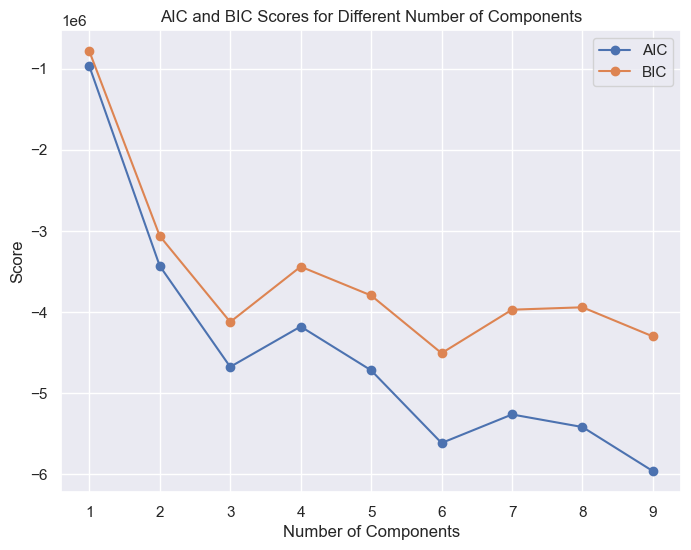

Optimal number of components: 6


In [9]:
uif.findGaussianMixtureComponents(df, RANDOM_STATE)

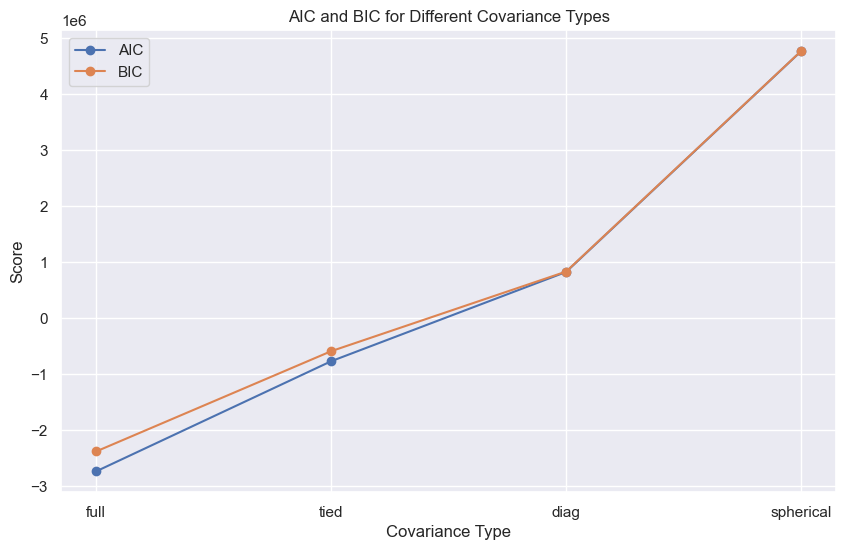

Optimal covariance type based on AIC: full


In [11]:
# covariance types to try
covariance_types = ['full', 'tied', 'diag', 'spherical']

# Function to evaluate GMM with different covariance types
def evaluate_gmm_with_covariance_types(X_train, covariance_types, n_components=2):
    aic_scores = []
    bic_scores = []
    best_models = {}

    for cov_type in covariance_types:
        gmm = GaussianMixture(n_components=n_components, covariance_type=cov_type, random_state=RANDOM_STATE)
        gmm.fit(X_train)
        
        # Store the AIC and BIC for each covariance type
        aic_scores.append(gmm.aic(X_train))
        bic_scores.append(gmm.bic(X_train))
        best_models[cov_type] = gmm

    return best_models, aic_scores, bic_scores

# evaluate GMM with different covariance types
best_models, aic_scores, bic_scores = evaluate_gmm_with_covariance_types(X_train, covariance_types, n_components=2)

# plot AIC and BIC to choose the best model
plt.figure(figsize=(10, 6))
plt.plot(covariance_types, aic_scores, label='AIC', marker='o')
plt.plot(covariance_types, bic_scores, label='BIC', marker='o')
plt.xlabel('Covariance Type')
plt.ylabel('Score')
plt.title('AIC and BIC for Different Covariance Types')
plt.legend()
plt.grid(True)
plt.show()

# choose the optimal covariance type based on AIC or BIC
optimal_covariance_type = covariance_types[np.argmin(aic_scores)]
print(f"Optimal covariance type based on AIC: {optimal_covariance_type}")

# Fit the best GMM model with the optimal covariance type
gmm_best = best_models[optimal_covariance_type]

# Predict the latent classes for the train and test sets
train_predictions = gmm_best.predict(X_train)
test_predictions = gmm_best.predict(X_test)

In [12]:
# Fit the Latent Class Analysis model (mixture model)
# Latent variables might be the number of classes you assume exist in your data
# Assuming we want to estimate 2 latent classes
X = df.values
k = 2  # Number of latent classes

# Fit a mixture model (Gaussian Mixture Model or similar can be applied here)
gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=RANDOM_STATE)
gmm.fit(X)

# Predict the latent class (cluster) for each observation
df['predicted_class'] = gmm.predict(X)

In [13]:
df[['Survival','predicted_class']].head()

,Survival,predicted_class
0,0,0
1,0,1
2,0,1
3,1,1
4,0,1


In [14]:
df.Survival.value_counts(), df.predicted_class.value_counts()

(Survival
 0    8274
 1    7427
 Name: count, dtype: int64,
 predicted_class
 1    13279
 0     2422
 Name: count, dtype: int64)

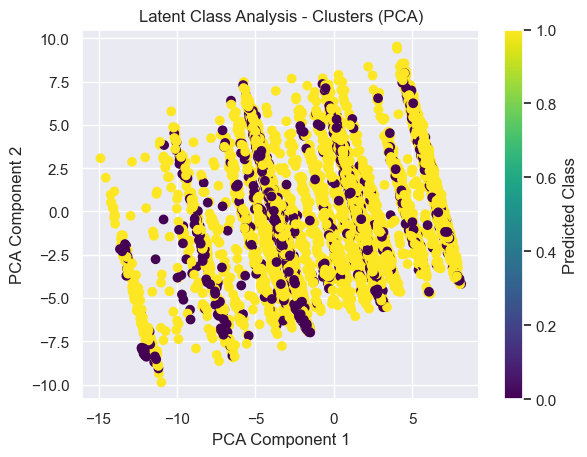

In [15]:
# Optionally, visualize the cluster assignments for the first two features
# Since the number of features is more than 2, you can visualize using PCA or just the first 2 dimensions for simplicity
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['predicted_class'], cmap='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Latent Class Analysis - Clusters (PCA)')
plt.colorbar(label='Predicted Class')
plt.show()

#### Gower distance differs from other distance metrics in several significant ways, especially in its ability to handle mixed data types.
1. Handling Mixed Data Types
    - Gower Distance: Specifically designed for datasets with mixed data types (numerical, categorical, binary, ordinal, etc.). It calculates distances differently for each type of variable and combines them into a single similarity score.

    - Other Distance Metrics:
        - Euclidean Distance: Works only with numerical data and assumes all features are on the same scale.
        - Manhattan Distance: Similar to Euclidean but uses absolute differences; still limited to numerical data.
        - Hamming Distance: Only applicable to binary or categorical data.

2. Normalization
    - Gower Distance: Normalizes numerical features by dividing the absolute difference by the feature’s range ($R_k$), ensuring all variables contribute equally regardless of scale.
        - Other Distance Metrics:
            - Euclidean and Manhattan distances require explicit normalization (e.g., MinMaxScaler or StandardScaler) before computation; otherwise, features with larger ranges dominate the result.

3. Categorical Data Handling
- Gower Distance: Assigns a similarity score of 1 if two categorical values are the same and 0 if they differ. This makes it ideal for datasets with nominal variables.
    - Other Distance Metrics:
        - Euclidean or Manhattan distances require one-hot encoding of categorical variables, which can disproportionately weight rare categories or inflate dimensionality.

4. Ordinal Data
    - Gower Distance: Can be extended to handle ordinal variables by incorporating rank-based differences (e.g., relative rank differences suggested by Podani).
        Other Distance Metrics: Typically treat ordinal variables as either numerical (if encoded) or categorical, losing the inherent order information.

5. Weighted Contributions
- Gower Distance: Allows assigning weights to individual features (w<sub>ijk</sub>) to control their influence on the overall distance calculation.
    - Other Distance Metrics: Most do not natively support feature weighting, requiring manual adjustments during preprocessing.

6. Interpretability
- Gower Distance: Produces a similarity score between 0 and 1, making it easy to interpret (0 = identical, 1 = completely dissimilar).
    - Other Distance Metrics:
        - Euclidean and Manhattan distances produce raw values that may be harder to interpret without normalization.

7. Use Cases
- Gower Distance: Ideal for clustering (e.g., k-modes, PAM), nearest neighbor searches, and other analyses involving mixed-type datasets.
    - Other Distance Metrics:
        - Euclidean and Manhattan distances are better suited for purely numerical datasets.
        - Hamming distance is limited to binary or categorical comparisons.

In [16]:
from gower import gower_matrix
from joblib import Parallel, delayed

# Define a function to compute pairwise Gower's distance for a subset of the data
def compute_gower_distance_subset(df_subset, full_data):
    return gower_matrix(df_subset, full_data)

# Split data into subsets and parallelize
num_cores = 12  # Number of cores you want to use
n_splits = num_cores  # Split the data into 12 subsets

# Assuming df is your actual dataframe
split_data = np.array_split(df, n_splits)

# Parallel computation of pairwise Gower's distance
gower_dist_matrix = Parallel(n_jobs=num_cores)(
    delayed(compute_gower_distance_subset)(subset, df) for subset in split_data
)

# Merge the results (you will need to combine these arrays back)
gower_dist_matrix = np.vstack(gower_dist_matrix)  # Stack the subsets to form the full distance matrix

/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [17]:
gower_dist_matrix.shape

(15701, 15701)

In [18]:
df.shape

(15701, 219)

### DBSCAN

In [19]:
from sklearn.cluster import DBSCAN

# apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=10, metric="precomputed") 
clusters = dbscan.fit_predict(gower_dist_matrix)

# Add cluster labels to data
df["DBSCAN_Cluster"] = clusters

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
0    15701
Name: count, dtype: int64


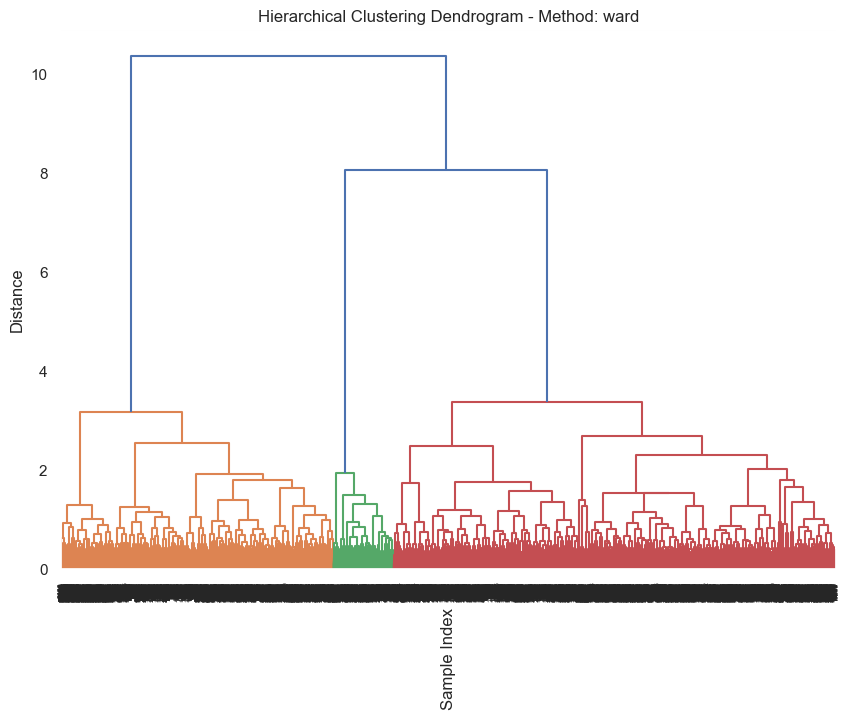

Cluster distribution for method ward:
F_Cluster
2    10172
1     5529
Name: count, dtype: int64


RecursionError: maximum recursion depth exceeded in __instancecheck__

<Figure size 1000x700 with 0 Axes>

In [20]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Ensure the distance matrix is symmetric
gower_dist_matrix = (gower_dist_matrix + gower_dist_matrix.T) / 2

# Convert to condensed form
condensed_gower_dist = squareform(gower_dist_matrix)

# Try different linkage methods
methods = ['ward', 'single', 'complete', 'average', 'centroid', 'median']

for method in methods:
    # Perform hierarchical clustering with the current method
    linkage_matrix = linkage(condensed_gower_dist, method=method)
    
    # Plot dendrogram
    plt.figure(figsize=(10, 7))
    dendrogram(linkage_matrix)
    plt.title(f'Hierarchical Clustering Dendrogram - Method: {method}')
    plt.xlabel('Sample Index', rotation=90)
    plt.ylabel('Distance')
    plt.show()
    
    # Cut the dendrogram to get exactly 2 clusters
    clusters = fcluster(linkage_matrix, t=2, criterion='maxclust')  # Forces exactly 2 clusters

    # Add cluster labels to the original dataframe
    df['F_Cluster'] = clusters

    # Print the number of samples in each cluster
    print(f"Cluster distribution for method {method}:")
    print(df['F_Cluster'].value_counts())